In [0]:
patients_df = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/Volumes/final_cap/default/healthcare/He_patients.csv")

patients_df.show()

+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|
+----------+------------+---------+-----------+---+------+----------------+



In [0]:
doctors_df = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/Volumes/final_cap/default/healthcare/doctors.csv")

doctors_df.show()

+---------+-----------+-----------+---------+----------------+
|doctor_id|doctor_name| department|     city|consultation_fee|
+---------+-----------+-----------+---------+----------------+
|     D101| Dr. Ramesh| Cardiology|Hyderabad|            1500|
|     D102|  Dr. Priya|  Neurology|Bangalore|            2000|
|     D103|  Dr. Anita|Dermatology|  Chennai|            1000|
|     D104| Dr. Suresh|Orthopedics|   Mumbai|            2500|
|     D105|  Dr. Meera| Pediatrics|    Delhi|            1200|
|     D106|  Dr. Kiran| Cardiology|Hyderabad|            3000|
+---------+-----------+-----------+---------+----------------+



In [0]:
appointments_df = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/Volumes/final_cap/default/healthcare/He_appointments.csv")

appointments_df.show()

+--------------+----------+---------+----------------+--------------+----------+
|appointment_id|patient_id|doctor_id|appointment_date|     diagnosis|bill_amoun|
+--------------+----------+---------+----------------+--------------+----------+
|         A1001|      P101|     D101|      2026-06-01| Heart Checkup|      5000|
|         A1002|      P102|     D102|      2026-06-01|      Migraine|      3500|
|         A1003|      P103|     D103|      2026-06-02|  Skin Allergy|      2000|
|         A1004|      P104|     D104|      2026-06-02|      Fracture|     12000|
|         A1005|      P105|     D105|      2026-06-03|         Fever|      1500|
|         A1006|      P106|     D106|      2026-06-03| Heart Checkup|      7000|
|         A1007|      P107|     D101|      2026-06-04|    Chest Pain|      5500|
|         A1008|      P108|     D103|      2026-06-04|Skin Infection|      2500|
|         A1009|      P101|     D106|      2026-06-05|Cardiac Review|      6500|
|         A1010|      P104| 

In [0]:
preferences_df = spark.read \
    .option("multiline", "true") \
    .json("/Volumes/final_cap/default/healthcare/He_patient_preferences.json")

preferences_df.show(truncate=False)

+----------------------------+----------+------------------+
|contact                     |patient_id|preferred_hospital|
+----------------------------+----------+------------------+
|{rahul@mail.com, 9876500011}|P101      |Apollo Hospital   |
|{priya@mail.com, 9876500012}|P102      |Yashoda Hospital  |
|{sneha@mail.com, 9876500014}|P104      |Care Hospital     |
|{meera@mail.com, 9876500018}|P108      |Apollo Hospital   |
+----------------------------+----------+------------------+



In [0]:
print("Patients Schema")
patients_df.printSchema()

print("Doctors Schema")
doctors_df.printSchema()

print("Appointments Schema")
appointments_df.printSchema()

print("Preferences Schema")
preferences_df.printSchema()

Patients Schema
root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

Doctors Schema
root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)

Appointments Schema
root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amoun: integer (nullable = true)

Preferences Schema
root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable

In [0]:
patients_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/bronze/patients")

In [0]:
doctors_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/bronze/doctors")

In [0]:
appointments_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/bronze/appointments")

In [0]:
preferences_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/bronze/preferences")

In [0]:
display(spark.read.format("delta").load("/bronze/patients"))
display(spark.read.format("delta").load("/bronze/doctors"))
display(spark.read.format("delta").load("/bronze/appointments"))
display(spark.read.format("delta").load("/bronze/preferences"))

patient_id,patient_name,city,state,age,gender,insurance_status
P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active
P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active
P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive
P104,Sneha Patel,Delhi,Delhi,31,Female,Active
P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active
P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive
P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active
P108,Meera Nair,Kochi,Kerala,48,Female,Active


doctor_id,doctor_name,department,city,consultation_fee
D101,Dr. Ramesh,Cardiology,Hyderabad,1500
D102,Dr. Priya,Neurology,Bangalore,2000
D103,Dr. Anita,Dermatology,Chennai,1000
D104,Dr. Suresh,Orthopedics,Mumbai,2500
D105,Dr. Meera,Pediatrics,Delhi,1200
D106,Dr. Kiran,Cardiology,Hyderabad,3000


appointment_id,patient_id,doctor_id,appointment_date,diagnosis,bill_amoun
A1001,P101,D101,2026-06-01,Heart Checkup,5000
A1002,P102,D102,2026-06-01,Migraine,3500
A1003,P103,D103,2026-06-02,Skin Allergy,2000
A1004,P104,D104,2026-06-02,Fracture,12000
A1005,P105,D105,2026-06-03,Fever,1500
A1006,P106,D106,2026-06-03,Heart Checkup,7000
A1007,P107,D101,2026-06-04,Chest Pain,5500
A1008,P108,D103,2026-06-04,Skin Infection,2500
A1009,P101,D106,2026-06-05,Cardiac Review,6500
A1010,P104,D104,2026-06-05,Back Pain,4500


contact,patient_id,preferred_hospital
"List(rahul@mail.com, 9876500011)",P101,Apollo Hospital
"List(priya@mail.com, 9876500012)",P102,Yashoda Hospital
"List(sneha@mail.com, 9876500014)",P104,Care Hospital
"List(meera@mail.com, 9876500018)",P108,Apollo Hospital


In [0]:
from pyspark.sql.functions import col, count, when

patients_df.select([count(when(col(c).isNull(), c)).alias(c) for c in patients_df.columns]).show()

+----------+------------+----+-----+---+------+----------------+
|patient_id|patient_name|city|state|age|gender|insurance_status|
+----------+------------+----+-----+---+------+----------------+
|         0|           0|   0|    0|  0|     0|               0|
+----------+------------+----+-----+---+------+----------------+



In [0]:
doctors_df.select([count(when(col(c).isNull(), c)).alias(c) for c in doctors_df.columns]).show()

+---------+-----------+----------+----+----------------+
|doctor_id|doctor_name|department|city|consultation_fee|
+---------+-----------+----------+----+----------------+
|        0|          0|         0|   0|               0|
+---------+-----------+----------+----+----------------+



In [0]:
appointments_df.select([count(when(col(c).isNull(), c)).alias(c) for c in appointments_df.columns]).show()

+--------------+----------+---------+----------------+---------+----------+
|appointment_id|patient_id|doctor_id|appointment_date|diagnosis|bill_amoun|
+--------------+----------+---------+----------------+---------+----------+
|             0|         0|        0|               0|        0|         0|
+--------------+----------+---------+----------------+---------+----------+



In [0]:
patients_df = patients_df.na.fill("Unknown")
doctors_df = doctors_df.na.fill("Unknown")
appointments_df = appointments_df.na.fill("Unknown")

In [0]:
from pyspark.sql.functions import col

preferences_flat_df = preferences_df.select(
    "patient_id",
    "preferred_hospital",
    col("contact.phone").alias("phone"),
    col("contact.email").alias("email")
)

preferences_flat_df.show()

+----------+------------------+----------+--------------+
|patient_id|preferred_hospital|     phone|         email|
+----------+------------------+----------+--------------+
|      P101|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102|  Yashoda Hospital|9876500012|priya@mail.com|
|      P104|     Care Hospital|9876500014|sneha@mail.com|
|      P108|   Apollo Hospital|9876500018|meera@mail.com|
+----------+------------------+----------+--------------+



In [0]:
patient_pref_df = patients_df.join(
    preferences_flat_df,
    on="patient_id",
    how="left"
)

patient_pref_df.show()

+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|     phone|         email|
+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|  Yashoda Hospital|9876500012|priya@mail.com|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|              NULL|      NULL|          NULL|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|     Care Hospital|9876500014|sneha@mail.com|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|              NULL|      NULL|          NULL|
|      P106|  Neha Singh|     Pu

In [0]:
appointment_patient_df = appointments_df.join(
    patient_pref_df,
    on="patient_id",
    how="inner"
)

appointment_patient_df.show()

+----------+--------------+---------+----------------+--------------+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|patient_id|appointment_id|doctor_id|appointment_date|     diagnosis|bill_amoun|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|     phone|         email|
+----------+--------------+---------+----------------+--------------+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|      P101|         A1009|     D106|      2026-06-05|Cardiac Review|      6500|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102|         A1002|     D102|      2026-06-01|      Migraine|      3500| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|  Yashoda Hospital|9876500012|priya@mail.com|
|      P103|         A1003|     D103|      2026-06-02| 

In [0]:
final_df = appointment_patient_df.join(
    doctors_df,
    on="doctor_id",
    how="inner"
)

final_df.show()

+---------+----------+--------------+----------------+--------------+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+-----------+-----------+---------+----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amoun|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|     phone|         email|doctor_name| department|     city|consultation_fee|
+---------+----------+--------------+----------------+--------------+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+-----------+-----------+---------+----------------+
|     D106|      P101|         A1009|      2026-06-05|Cardiac Review|      6500|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|  Dr. Kiran| Cardiology|Hyderabad|            3000|
|     D102|      P102|         A1002|   

In [0]:
appointments_df = appointments_df.withColumnRenamed(
    "bill_amoun",
    "bill_amount"
)

In [0]:
appointment_patient_df = appointments_df.join(
    patient_pref_df,
    on="patient_id",
    how="inner"
)

final_df = appointment_patient_df.join(
    doctors_df,
    on="doctor_id",
    how="inner"
)

In [0]:
final_df = final_df.withColumn(
    "final_bill",
    col("bill_amount") + col("consultation_fee")
)
final_df.show()

+---------+----------+--------------+----------------+--------------+-----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+-----------+-----------+---------+----------------+----------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|     phone|         email|doctor_name| department|     city|consultation_fee|final_bill|
+---------+----------+--------------+----------------+--------------+-----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+-----------+-----------+---------+----------------+----------+
|     D106|      P101|         A1009|      2026-06-05|Cardiac Review|       6500|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|  Dr. Kiran| Cardiology|Hyderabad|            3000|    

In [0]:
from pyspark.sql.functions import month

final_df = final_df.withColumn(
    "appointment_month",
    month("appointment_date")
)

final_df.select(
    "appointment_date",
    "appointment_month"
).show()

+----------------+-----------------+
|appointment_date|appointment_month|
+----------------+-----------------+
|      2026-06-05|                6|
|      2026-06-01|                6|
|      2026-06-02|                6|
|      2026-06-05|                6|
|      2026-06-03|                6|
|      2026-06-03|                6|
|      2026-06-04|                6|
|      2026-06-04|                6|
|      2026-06-01|                6|
|      2026-06-02|                6|
+----------------+-----------------+



In [0]:
from pyspark.sql.functions import when

final_df = final_df.withColumn(
    "patient_age_group",
    when(col("age") >= 50, "Senior")
    .when(col("age") >= 30, "Adult")
    .otherwise("Young")
)

final_df.select(
    "patient_name",
    "age",
    "patient_age_group"
).show()

+------------+---+-----------------+
|patient_name|age|patient_age_group|
+------------+---+-----------------+
|Rahul Sharma| 35|            Adult|
| Priya Reddy| 29|            Young|
|  Amit Kumar| 42|            Adult|
| Sneha Patel| 31|            Adult|
|  Farhan Ali| 55|           Senior|
|  Neha Singh| 38|            Adult|
| Arjun Verma| 26|            Young|
|  Meera Nair| 48|            Adult|
|Rahul Sharma| 35|            Adult|
| Sneha Patel| 31|            Adult|
+------------+---+-----------------+



In [0]:
doctors_df = doctors_df.withColumnRenamed("city", "doctor_city")

In [0]:
final_df = appointment_patient_df.join(
    doctors_df,
    on="doctor_id",
    how="inner"
)

In [0]:
final_df.printSchema()

root
 |-- doctor_id: string (nullable = false)
 |-- patient_id: string (nullable = false)
 |-- appointment_id: string (nullable = false)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = false)
 |-- bill_amount: integer (nullable = true)
 |-- patient_name: string (nullable = false)
 |-- city: string (nullable = false)
 |-- state: string (nullable = false)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = false)
 |-- insurance_status: string (nullable = false)
 |-- preferred_hospital: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- email: string (nullable = true)
 |-- doctor_name: string (nullable = false)
 |-- department: string (nullable = false)
 |-- doctor_city: string (nullable = false)
 |-- consultation_fee: integer (nullable = true)



In [0]:
from pyspark.sql.functions import *

final_df = final_df.withColumn(
    "final_bill",
    col("bill_amount") + col("consultation_fee")
)

final_df = final_df.withColumn(
    "appointment_month",
    month("appointment_date")
)

final_df = final_df.withColumn(
    "patient_age_group",
    when(col("age") >= 50, "Senior")
    .when(col("age") >= 30, "Adult")
    .otherwise("Young")
)

final_df.write.format("delta") \
.mode("overwrite") \
.save("/silver/healthcare")

In [0]:
final_df.createOrReplaceTempView("healthcare")

In [0]:
%sql
SHOW TABLES;

database,tableName,isTemporary
,healthcare,true


In [0]:
%sql
SELECT
SUM(final_bill) AS total_revenue
FROM healthcare;

total_revenue
69200


In [0]:
%sql
SELECT
department,
SUM(final_bill) AS revenue
FROM healthcare
GROUP BY department
ORDER BY revenue DESC;

department,revenue
Cardiology,33000
Orthopedics,21500
Dermatology,6500
Neurology,5500
Pediatrics,2700


In [0]:
%sql
SELECT
city,
SUM(final_bill) AS revenue
FROM healthcare
GROUP BY city
ORDER BY revenue DESC;

city,revenue
Hyderabad,23000
Delhi,21500
Pune,10000
Bangalore,5500
Kochi,3500
Mumbai,3000
Chennai,2700


In [0]:
%sql
DESCRIBE healthcare;

col_name,data_type,comment
doctor_id,string,null
patient_id,string,null
appointment_id,string,null
appointment_date,date,null
diagnosis,string,null
bill_amount,int,null
patient_name,string,null
city,string,null
state,string,null
age,int,null


In [0]:
status_data = [
("A1001","Completed"),
("A1002","Completed"),
("A1003","Pending"),
("A1004","Completed"),
("A1005","Completed"),
("A1006","Completed"),
("A1007","Completed"),
("A1008","Pending"),
("A1009","Completed"),
("A1010","Cancelled")
]

status_df = spark.createDataFrame(status_data, ["appointment_id","status"])

In [0]:
appointments_df = appointments_df.join(status_df, "appointment_id", "left")

In [0]:
appointment_patient_df = appointments_df.join(patient_pref_df, "patient_id")
final_df = appointment_patient_df.join(doctors_df, "doctor_id")

final_df.createOrReplaceTempView("healthcare")

In [0]:
%sql
SELECT COUNT(*)
FROM healthcare
WHERE status = 'Completed';

COUNT(*)
7


In [0]:
%sql
DESCRIBE healthcare;

col_name,data_type,comment
doctor_id,string,null
patient_id,string,null
appointment_id,string,null
appointment_date,date,null
diagnosis,string,null
bill_amount,int,null
status,string,null
patient_name,string,null
city,string,null
state,string,null


In [0]:
from pyspark.sql.functions import col

final_df = final_df.withColumn(
    "final_bill",
    col("bill_amount") + col("consultation_fee")
)

In [0]:
final_df.createOrReplaceTempView("healthcare")

In [0]:
%sql
SELECT
    patient_name,
    SUM(final_bill) AS total_bill
FROM healthcare
GROUP BY patient_name
ORDER BY total_bill DESC;

patient_name,total_bill
Sneha Patel,21500
Rahul Sharma,16000
Neha Singh,10000
Arjun Verma,7000
Priya Reddy,5500
Meera Nair,3500
Amit Kumar,3000
Farhan Ali,2700


In [0]:
from pyspark.sql.functions import sum, desc
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

doctor_revenue = final_df.groupBy("doctor_name") \
    .agg(sum("final_bill").alias("doctor_revenue"))

window_spec = Window.orderBy(desc("doctor_revenue"))

doctor_rank = doctor_revenue.withColumn(
    "rank",
    rank().over(window_spec)
)

doctor_rank.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+--------------+----+
|doctor_name|doctor_revenue|rank|
+-----------+--------------+----+
| Dr. Suresh|         21500|   1|
|  Dr. Kiran|         19500|   2|
| Dr. Ramesh|         13500|   3|
|  Dr. Anita|          6500|   4|
|  Dr. Priya|          5500|   5|
|  Dr. Meera|          2700|   6|
+-----------+--------------+----+



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
department_revenue = final_df.groupBy("department") \
    .agg(sum("final_bill").alias("dept_revenue"))

window_spec = Window.orderBy(desc("dept_revenue"))

department_rank = department_revenue.withColumn(
    "rank",
    rank().over(window_spec)
)

department_rank.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+------------+----+
| department|dept_revenue|rank|
+-----------+------------+----+
| Cardiology|       33000|   1|
|Orthopedics|       21500|   2|
|Dermatology|        6500|   3|
|  Neurology|        5500|   4|
| Pediatrics|        2700|   5|
+-----------+------------+----+



In [0]:
from pyspark.sql.functions import dense_rank

patient_bill = final_df.groupBy("patient_name") \
    .agg(sum("final_bill").alias("total_bill"))

window_spec = Window.orderBy(desc("total_bill"))

top_patients = patient_bill.withColumn(
    "rank",
    dense_rank().over(window_spec)
).filter("rank <= 3")

top_patients.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+----------+----+
|patient_name|total_bill|rank|
+------------+----------+----+
| Sneha Patel|     21500|   1|
|Rahul Sharma|     16000|   2|
|  Neha Singh|     10000|   3|
+------------+----------+----+



In [0]:
from pyspark.sql.functions import row_number

doctor_dept_revenue = final_df.groupBy(
    "department",
    "doctor_name"
).agg(
    sum("final_bill").alias("revenue")
)

window_spec = Window.partitionBy("department") \
                    .orderBy(desc("revenue"))

top_doctors = doctor_dept_revenue.withColumn(
    "row_num",
    row_number().over(window_spec)
).filter("row_num = 1")

top_doctors.show()

+-----------+-----------+-------+-------+
| department|doctor_name|revenue|row_num|
+-----------+-----------+-------+-------+
| Cardiology|  Dr. Kiran|  19500|      1|
|Dermatology|  Dr. Anita|   6500|      1|
|  Neurology|  Dr. Priya|   5500|      1|
|Orthopedics| Dr. Suresh|  21500|      1|
| Pediatrics|  Dr. Meera|   2700|      1|
+-----------+-----------+-------+-------+



In [0]:
from pyspark.sql.functions import sum

window_spec = Window.orderBy("appointment_date")

running_revenue_df = final_df.withColumn(
    "running_revenue",
    sum("final_bill").over(window_spec)
)



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
running_revenue_df.select(
    "appointment_date",
    "final_bill",
    "running_revenue"
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------------+----------+---------------+
|appointment_date|final_bill|running_revenue|
+----------------+----------+---------------+
|      2026-06-01|      6500|          12000|
|      2026-06-01|      5500|          12000|
|      2026-06-02|      3000|          29500|
|      2026-06-02|     14500|          29500|
|      2026-06-03|      2700|          42200|
|      2026-06-03|     10000|          42200|
|      2026-06-04|      7000|          52700|
|      2026-06-04|      3500|          52700|
|      2026-06-05|      9500|          69200|
|      2026-06-05|      7000|          69200|
+----------------+----------+---------------+



In [0]:
final_df.write.format("delta") \
.mode("overwrite") \
.save("/delta/healthcare")

In [0]:
final_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("healthcare_delta")

In [0]:
final_df.createOrReplaceTempView("healthcare")

In [0]:
%sql
CREATE TABLE healthcare_sql
USING DELTA
AS
SELECT * FROM healthcare;

num_affected_rows,num_inserted_rows


In [0]:
%sql DESCRIBE HISTORY healthcare_delta;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T05:30:51.000Z,144600303012599,azuser7231_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(425717110120112),c93b55e0-68c7-4008-9c2d-2153fa77ee91,0622-042658-q3x3lo8h-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 6500)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
df_old = spark.read.format("delta") \
.option("versionAsOf",0) \
.table("healthcare_delta")

display(df_old)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,preferred_hospital,phone,email,doctor_name,department,doctor_city,consultation_fee,final_bill
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500,6500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000,5500
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,null,Dr. Anita,Dermatology,Chennai,1000,3000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500,14500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,null,Dr. Meera,Pediatrics,Delhi,1200,2700
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,null,Dr. Kiran,Cardiology,Hyderabad,3000,10000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,null,Dr. Ramesh,Cardiology,Hyderabad,1500,7000
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com,Dr. Anita,Dermatology,Chennai,1000,3500
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000,9500
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500,7000


In [0]:
update_data = [
("P101","Mumbai","Inactive"),
("P104","Delhi","Active")
]

updates_df = spark.createDataFrame(
update_data,
["patient_id","city","insurance_status"]
)

updates_df.write.format("delta") \
.mode("overwrite") \
.saveAsTable("patient_updates")

In [0]:
%sql
MERGE INTO healthcare_delta t
USING patient_updates s
ON t.patient_id = s.patient_id

WHEN MATCHED THEN
UPDATE SET
t.city = s.city,
t.insurance_status = s.insurance_status

num_affected_rows,num_updated_rows,num_deleted_rows,num_inserted_rows
4,4,0,0


In [0]:
%sql
OPTIMIZE healthcare_delta;

path,metrics
abfss://unity-catalog-storage@dbstoragexilgy5hegv2j6.dfs.core.windows.net/7405614861709757/__unitystorage/catalogs/1415a91c-1c51-403e-bfac-1f91383c9582/tables/45084999-fa7c-4dcb-b811-328541c5ee30,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782106454721, 1782106455209, 8, 0, null, List(0, 0), null, 21, 21, 0, 0, null, null)"


In [0]:
%sql
OPTIMIZE healthcare_delta
ZORDER BY (patient_id);

path,metrics
abfss://unity-catalog-storage@dbstoragexilgy5hegv2j6.dfs.core.windows.net/7405614861709757/__unitystorage/catalogs/1415a91c-1c51-403e-bfac-1f91383c9582/tables/45084999-fa7c-4dcb-b811-328541c5ee30,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 6611), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782106505016, 1782106505716, 8, 0, null, List(0, 0), null, 21, 21, 0, 0, null, null)"


In [0]:
%sql
VACUUM healthcare_delta;

path
abfss://unity-catalog-storage@dbstoragexilgy5hegv2j6.dfs.core.windows.net/7405614861709757/__unitystorage/catalogs/1415a91c-1c51-403e-bfac-1f91383c9582/tables/45084999-fa7c-4dcb-b811-328541c5ee30


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

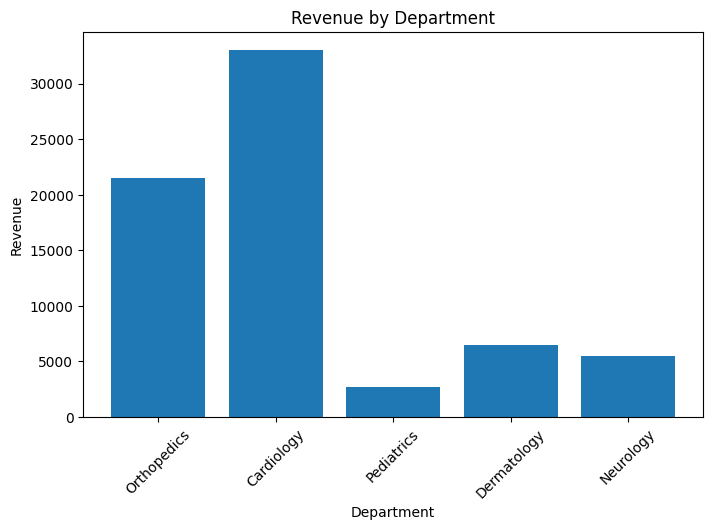

In [0]:
dept_df = final_df.groupBy("department") \
                  .sum("final_bill") \
                  .toPandas()

dept_df.columns = ["department", "revenue"]

plt.figure(figsize=(8,5))
plt.bar(dept_df["department"], dept_df["revenue"])
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.title("Revenue by Department")
plt.xticks(rotation=45)
plt.show()

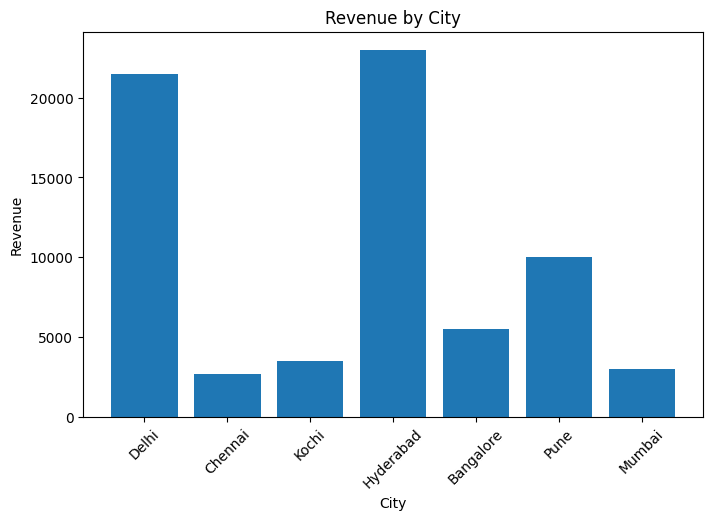

In [0]:
city_df = final_df.groupBy("city") \
                  .sum("final_bill") \
                  .toPandas()

city_df.columns = ["city", "revenue"]

plt.figure(figsize=(8,5))
plt.bar(city_df["city"], city_df["revenue"])
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

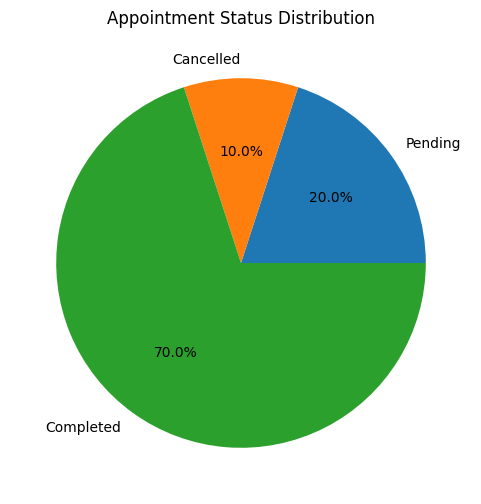

In [0]:
status_df = final_df.groupBy("status") \
                    .count() \
                    .toPandas()

plt.figure(figsize=(6,6))
plt.pie(status_df["count"],
        labels=status_df["status"],
        autopct='%1.1f%%')

plt.title("Appointment Status Distribution")
plt.show()

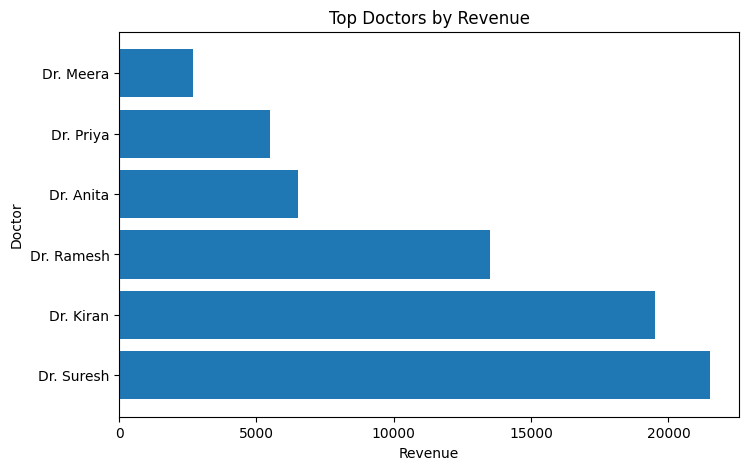

In [0]:
doctor_df = final_df.groupBy("doctor_name") \
                    .sum("final_bill") \
                    .orderBy("sum(final_bill)", ascending=False) \
                    .toPandas()

doctor_df.columns = ["doctor_name", "revenue"]

plt.figure(figsize=(8,5))
plt.barh(doctor_df["doctor_name"], doctor_df["revenue"])
plt.xlabel("Revenue")
plt.ylabel("Doctor")
plt.title("Top Doctors by Revenue")
plt.show()

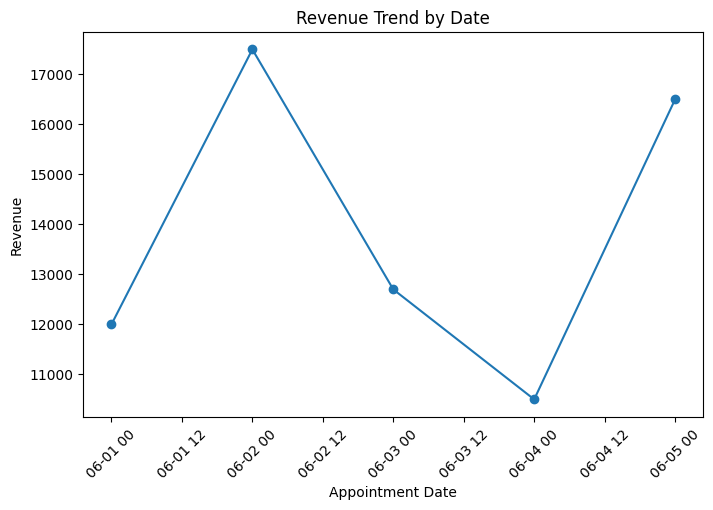

In [0]:
trend_df = final_df.groupBy("appointment_date") \
                   .sum("final_bill") \
                   .orderBy("appointment_date") \
                   .toPandas()

trend_df.columns = ["appointment_date", "revenue"]

plt.figure(figsize=(8,5))
plt.plot(trend_df["appointment_date"], trend_df["revenue"], marker='o')

plt.xlabel("Appointment Date")
plt.ylabel("Revenue")
plt.title("Revenue Trend by Date")
plt.xticks(rotation=45)
plt.show()

In [0]:
%sql
CREATE TABLE managed_healthcare
USING DELTA
AS
SELECT * FROM healthcare;

num_affected_rows,num_inserted_rows


In [0]:
final_df.write.format("delta") \
.mode("overwrite") \
.save("/external/healthcare")

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW temp_healthcare AS
SELECT * FROM healthcare;

In [0]:
%sql
CREATE OR REPLACE GLOBAL TEMP VIEW global_healthcare AS
SELECT * FROM healthcare;

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-6798827642336086>, line 1
----> 1 get_ipython().run_cell_magic('sql', '', 'CREATE OR REPLACE GLOBAL TEMP VIEW global_healthcare AS\nSELECT * FROM healthcare;\n')

File /databricks/python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2541, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2539 with self.builtin_trap:
   2540     args = (magic_arg_s, cell)
-> 2541     result = fn(*args, **kwargs)
   2543 # The code below prevents the output from being displayed
   2544 # when using magics with decorator @output_can_be_silenced
   2545 # when the last Python token in the expression is a ';'.
   2546 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /databricks/python_shell/lib/dbruntime/sql_magic/sql_magic.py:213, in SqlMagic.sql(self, line, cell)
    206 except BaseException a